In [2]:
# Libraries

import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm


sys.path.append('../')
from simulation.config import *

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
dataset = np.load('../particle_dataset.npy')  # Shape: (100, 303, 100, 4)
print(f'Dataset shape: {dataset.shape}')

Dataset shape: (100, 304, 100, 10)


In [4]:
num_trials, max_timesteps, num_particles, num_features = dataset.shape
print(f'Number of trials: {num_trials}', 
      f'Max timesteps: {max_timesteps}',
      f'Number of particles: {num_particles}',
      f'Number of features: {num_features}', sep='\n')

Number of trials: 100
Max timesteps: 304
Number of particles: 100
Number of features: 10


In [5]:
# Select a single particle
particle_idx = 0
single_particle_data = dataset[:, :, particle_idx, :]  # Shape: (100, 303, 11)

# Create input-output pairs using normalized data
N, T_max, _ = single_particle_data.shape
inputs = []
targets = []

for trial_idx in range(N):
    for t in range(T_max - 1):  # T_max-1 to get next state
        # Input: [x, y, vx, vy, e, vx0, vy0, g, Δt, x_min, x_max]
        input_vec = single_particle_data[trial_idx, t, :]
        # Target: Next state [x(t+Δt), y(t+Δt)]
        target_vec = single_particle_data[trial_idx, t + 1, :2]  
        inputs.append(input_vec)
        targets.append(target_vec)

inputs = np.array(inputs, dtype=np.float32)  # Shape: (N*(T_max-1), 10)
targets = np.array(targets, dtype=np.float32)  # Shape: (N*(T_max-1), 2)
print(f'Inputs shape: {inputs.shape}, Targets shape: {targets.shape}')

Inputs shape: (30300, 10), Targets shape: (30300, 2)


In [6]:
sys.path.append('..')
from models.model_architectures import ParticleNet, ParticleNetSCFC 

In [7]:
inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
targets = torch.tensor(targets, dtype=torch.float32).to(device)

# Dataset Split (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(inputs, targets, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f'Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}')

Train: torch.Size([24240, 10]), Validation: torch.Size([3030, 10]), Test: torch.Size([3030, 10])


In [15]:
model = ParticleNetSCFC().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [16]:
# Training Loop with tqdm
num_epochs = 100
batch_size = 128
train_losses = []
val_losses = []

for epoch in tqdm(range(num_epochs), desc="Training Epochs"):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    
    # Mini-batch training
    epoch_train_loss = 0
    for i in range(0, X_train.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_X = X_train[indices]
        batch_y = y_train[indices]
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item() * batch_X.size(0)
    
    epoch_train_loss /= X_train.size(0)
    train_losses.append(epoch_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val).item()
        val_losses.append(val_loss)
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {epoch_train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}')

Training Epochs:  10%|█         | 10/100 [00:08<01:22,  1.10it/s]

Epoch [10/100], Train Loss: 382.257206, Val Loss: 412.339355


Training Epochs:  20%|██        | 20/100 [00:17<01:07,  1.19it/s]

Epoch [20/100], Train Loss: 374.756989, Val Loss: 403.941345


Training Epochs:  30%|███       | 30/100 [00:25<00:54,  1.29it/s]

...

Epoch [80/100], Train Loss: 372.571246, Val Loss: 402.068207


Training Epochs:  90%|█████████ | 90/100 [01:16<00:08,  1.20it/s]

Epoch [90/100], Train Loss: 372.947342, Val Loss: 404.104828


Training Epochs: 100%|██████████| 100/100 [01:24<00:00,  1.19it/s]

Epoch [100/100], Train Loss: 370.518531, Val Loss: 405.197296


In [12]:
# Evaluate on Test Set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    # Denormalize for loss computation in original scale
    test_outputs_np = test_outputs.cpu().numpy()
    y_test_np = y_test.cpu().numpy()
    # Compute test loss in original scale
    test_outputs_tensor = torch.tensor(test_outputs, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).to(device)
    test_loss = criterion(test_outputs_tensor, y_test_tensor).item()
    print(f'Test Loss: {test_loss:.6f}')


Test Loss: 380.308838


C:\Users\amine\AppData\Local\Temp\ipykernel_18140\1399715945.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_outputs_tensor = torch.tensor(test_outputs, dtype=torch.float32).to(device)


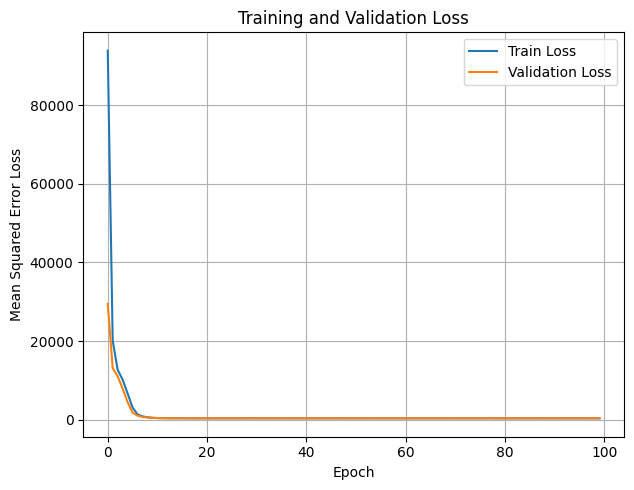

In [13]:
# %%
# Plot Training and Validation Metrics
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Save the Model
model_name = 'particle_net'
torch.save(model.state_dict(), f'../models/{model_name}.pth')
print(f'Model saved as {model_name}.pth')

Model saved as particle_net.pth
